In [1]:
import os


import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import dill



import TwoPUtils as tpu
import STX3KO_analyses as stx
from STX3KO_analyses import utilities_ES as u_es
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

pkl_basedir = '/home/mplitt/YMazeSessPkls'

In [4]:
import pickle 
with open('/home/mplitt/shuffle_pkls/place_field_shuff_results_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [5]:
def load_single_sess(mouse, d, verbose = True, pkl_basedir = '/home/mplitt/YMazeSessPkls'):
    pkldir = os.path.join(pkl_basedir, mouse)            
    
    sess = stx.session.YMazeSession.from_file(
            os.path.join(pkldir, d['date'], "%s_%d.pkl" % (d['scene'], d['session'])),
            verbose=verbose, novel_arm=d['novel_arm'])
    return sess

In [25]:
for mouse, sess_deets in stx.ymaze_sess_deets.KO_sessions.items():
    for day, deets in enumerate(sess_deets):
        if day <6:
            if not isinstance(deets,tuple):
                
                sess = u.add_sig_field_thresh(u.load_single_day(mouse, day),shuff_results[mouse][day])
                sess._abc_impl = None
                tpu.sess.save_session(sess,'/home/mplitt/YMazeSessPkls')
            else:
                if isinstance(deets,tuple):
                    #  load roi_aligner.pkl
                    _shuff_results = shuff_results[mouse][day]
                    comb_sess = u.load_single_day(mouse, day)

                    pkldir = os.path.join('/home/mplitt/YMazeSessPkls/', mouse)

                    with open(os.path.join(pkldir, "roi_aligner_results.pkl"), 'rb') as file:
                        match_inds = dill.load(file)
                    common_roi_mapping = u.common_rois(match_inds, [d['ravel_ind'] for d in deets])

                    for ind, _deets in enumerate(deets):
                        print(_deets)
                        sess = load_single_sess(mouse, _deets)

                        field_perm_masks = {'sig_bins': {}, 'cell_masks':{}}
                        for ttype in ('fam', 'nov'):
                            if ttype == 'nov':
                                trial_mask = sess.trial_info['LR']==sess.novel_arm
                                comb_trial_mask = comb_sess.trial_info['LR']==sess.novel_arm
                            else:
                                trial_mask = sess.trial_info['LR']!=sess.novel_arm 
                                comb_trial_mask = comb_sess.trial_info['LR']!=sess.novel_arm

                            comb_sig_bins = np.nanmean(comb_sess.trial_matrices['F_dff_th'][comb_trial_mask,:,:],axis=0)>_shuff_results[ttype]
                            sig_bins = np.zeros_like(np.nanmean(sess.trial_matrices['F_dff_th'][trial_mask,:,:],axis=0))
                            sig_bins[:, common_roi_mapping[ind,:]] = comb_sig_bins
                            field_perm_masks['sig_bins'][ttype] = sig_bins


                            sig_bin_count = (1.*sig_bins).sum(axis=0)
                            field_perm_masks['cell_masks'][ttype] = (sig_bin_count>1) * (sig_bin_count<25)
                        sess.field_perm_masks = field_perm_masks

                        sess._abc_impl = None
                        tpu.sess.save_session(sess,'/home/mplitt/YMazeSessPkls')

                    


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 6, 'scan': 14, 'novel_arm': -1, 'ravel_ind': 1}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_006_014.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_006_014.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.1/29_09_2020/YMaze_LNovel/YMaze_LNovel_001_003.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.1/29_09_2020/YMaze_LNovel/YMaze_LNovel_001_003.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 3}


...

{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.3/02_10_2020/YMaze_LNovel/YMaze_LNovel_001_003.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.3/02_10_2020/YMaze_LNovel/YMaze_LNovel_001_003.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': -1, 'ravel_ind': 5}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.3/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_006.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.3/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_006.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 4}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'ses

In [2]:
import pickle 
with open('/home/mplitt/shuffle_pkls/sparse_place_field_shuff_results_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [4]:

for mouse in sparse_mice:
    for day in range(6):
        for ttype in ('fam', 'nov'):
            sess = u_es.load_single_day(mouse, day, pkl_basedir='/home/mplitt/YMazeSessPkls')
            ch0_th = np.copy(sess.timeseries['channel_0_F_dff'])
            ch0_th -= .2
            ch0_th[ch0_th<0]=0
            sess.timeseries['channel_0_F_dff_th']=ch0_th
            sess.add_pos_binned_trial_matrix_mux('channel_0_F_dff_th', channel='channel_0')


            ch1_th = np.copy(sess.timeseries['channel_1_F_dff'])
            ch1_th -= .4
            ch1_th[ch1_th<0]=0
            sess.timeseries['channel_1_F_dff_th']=ch1_th
            sess.add_pos_binned_trial_matrix_mux('channel_1_F_dff_th', channel='channel_1')


            field_perm_masks = {'sig_bins': {'channel_0':{}, 'channel_1':{}}, 'cell_masks': {'channel_0':{}, 'channel_1':{}}}

            for ttype in ('fam', 'nov'):

                if ttype == 'fam':
                    trial_mask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    trial_mask = sess.trial_info['LR']==sess.novel_arm

                for chan in ('channel_0', 'channel_1'):
                    avg_mat = np.nanmean(sess.trial_matrices[f'{chan}_F_dff_th'][trial_mask,:,:],axis=0)
                
                    sig_bins = avg_mat>shuff_results[mouse][day][chan][ttype]
                    sig_bin_count = (1.*sig_bins).sum(axis=0)
                    cell_masks = (sig_bin_count>1) * (sig_bin_count<25)
                    field_perm_masks['sig_bins'][chan][ttype] = sig_bins
                    field_perm_masks['cell_masks'][chan][ttype] = cell_masks

            sess.field_perm_masks = field_perm_masks
            sess._abc_impl = None
            tpu.sess.save_session(sess,'/home/mplitt/YMazeSessPkls')


{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}
{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}
{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2}
{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2}
{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3}
{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3}
{'date': '19_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4}
{'date': '19_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4}
{'date': '20_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 12, 'novel_arm': -1, 'exp_day': 5}
{'date': '20_11_2024', 'scene': 'YMaze_LNovel', 'session'

/tmp/ipykernel_477080/4139575808.py:29: RuntimeWarning: Mean of empty slice
  avg_mat = np.nanmean(sess.trial_matrices[f'{chan}_F_dff_th'][trial_mask,:,:],axis=0)


{'date': '25_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': 1, 'exp_day': 2}


/tmp/ipykernel_477080/4139575808.py:29: RuntimeWarning: Mean of empty slice
  avg_mat = np.nanmean(sess.trial_matrices[f'{chan}_F_dff_th'][trial_mask,:,:],axis=0)


{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 3}
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 3}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 22, 'novel_arm': 1, 'exp_day': 4}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 22, 'novel_arm': 1, 'exp_day': 4}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 16, 'novel_arm': 1, 'exp_day': 5}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 16, 'novel_arm': 1, 'exp_day': 5}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 6}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 6}
{'date': '25_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'exp_day': 1}
{'date': '25_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 's

/home/mplitt/repos/TwoPUtils/TwoPUtils/spatial_analyses.py:74: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/tmp/ipykernel_477080/4139575808.py:29: RuntimeWarning: Mean of empty slice
  avg_mat = np.nanmean(sess.trial_matrices[f'{chan}_F_dff_th'][trial_mask,:,:],axis=0)


{'date': '31_05_2025', 'scene': 'YMaze_LNovel_LongTimeout', 'session': 2, 'scan': 3, 'novel_arm': -1, 'exp_day': 7}


/home/mplitt/repos/TwoPUtils/TwoPUtils/spatial_analyses.py:74: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/tmp/ipykernel_477080/4139575808.py:29: RuntimeWarning: Mean of empty slice
  avg_mat = np.nanmean(sess.trial_matrices[f'{chan}_F_dff_th'][trial_mask,:,:],axis=0)


In [53]:
cell_masks=field_perm_masks['cell_masks']['channel_1']['fam']
sigcells = np.argwhere(cell_masks).ravel()

trial_mask = sess.trial_info['LR']!=sess.novel_arm

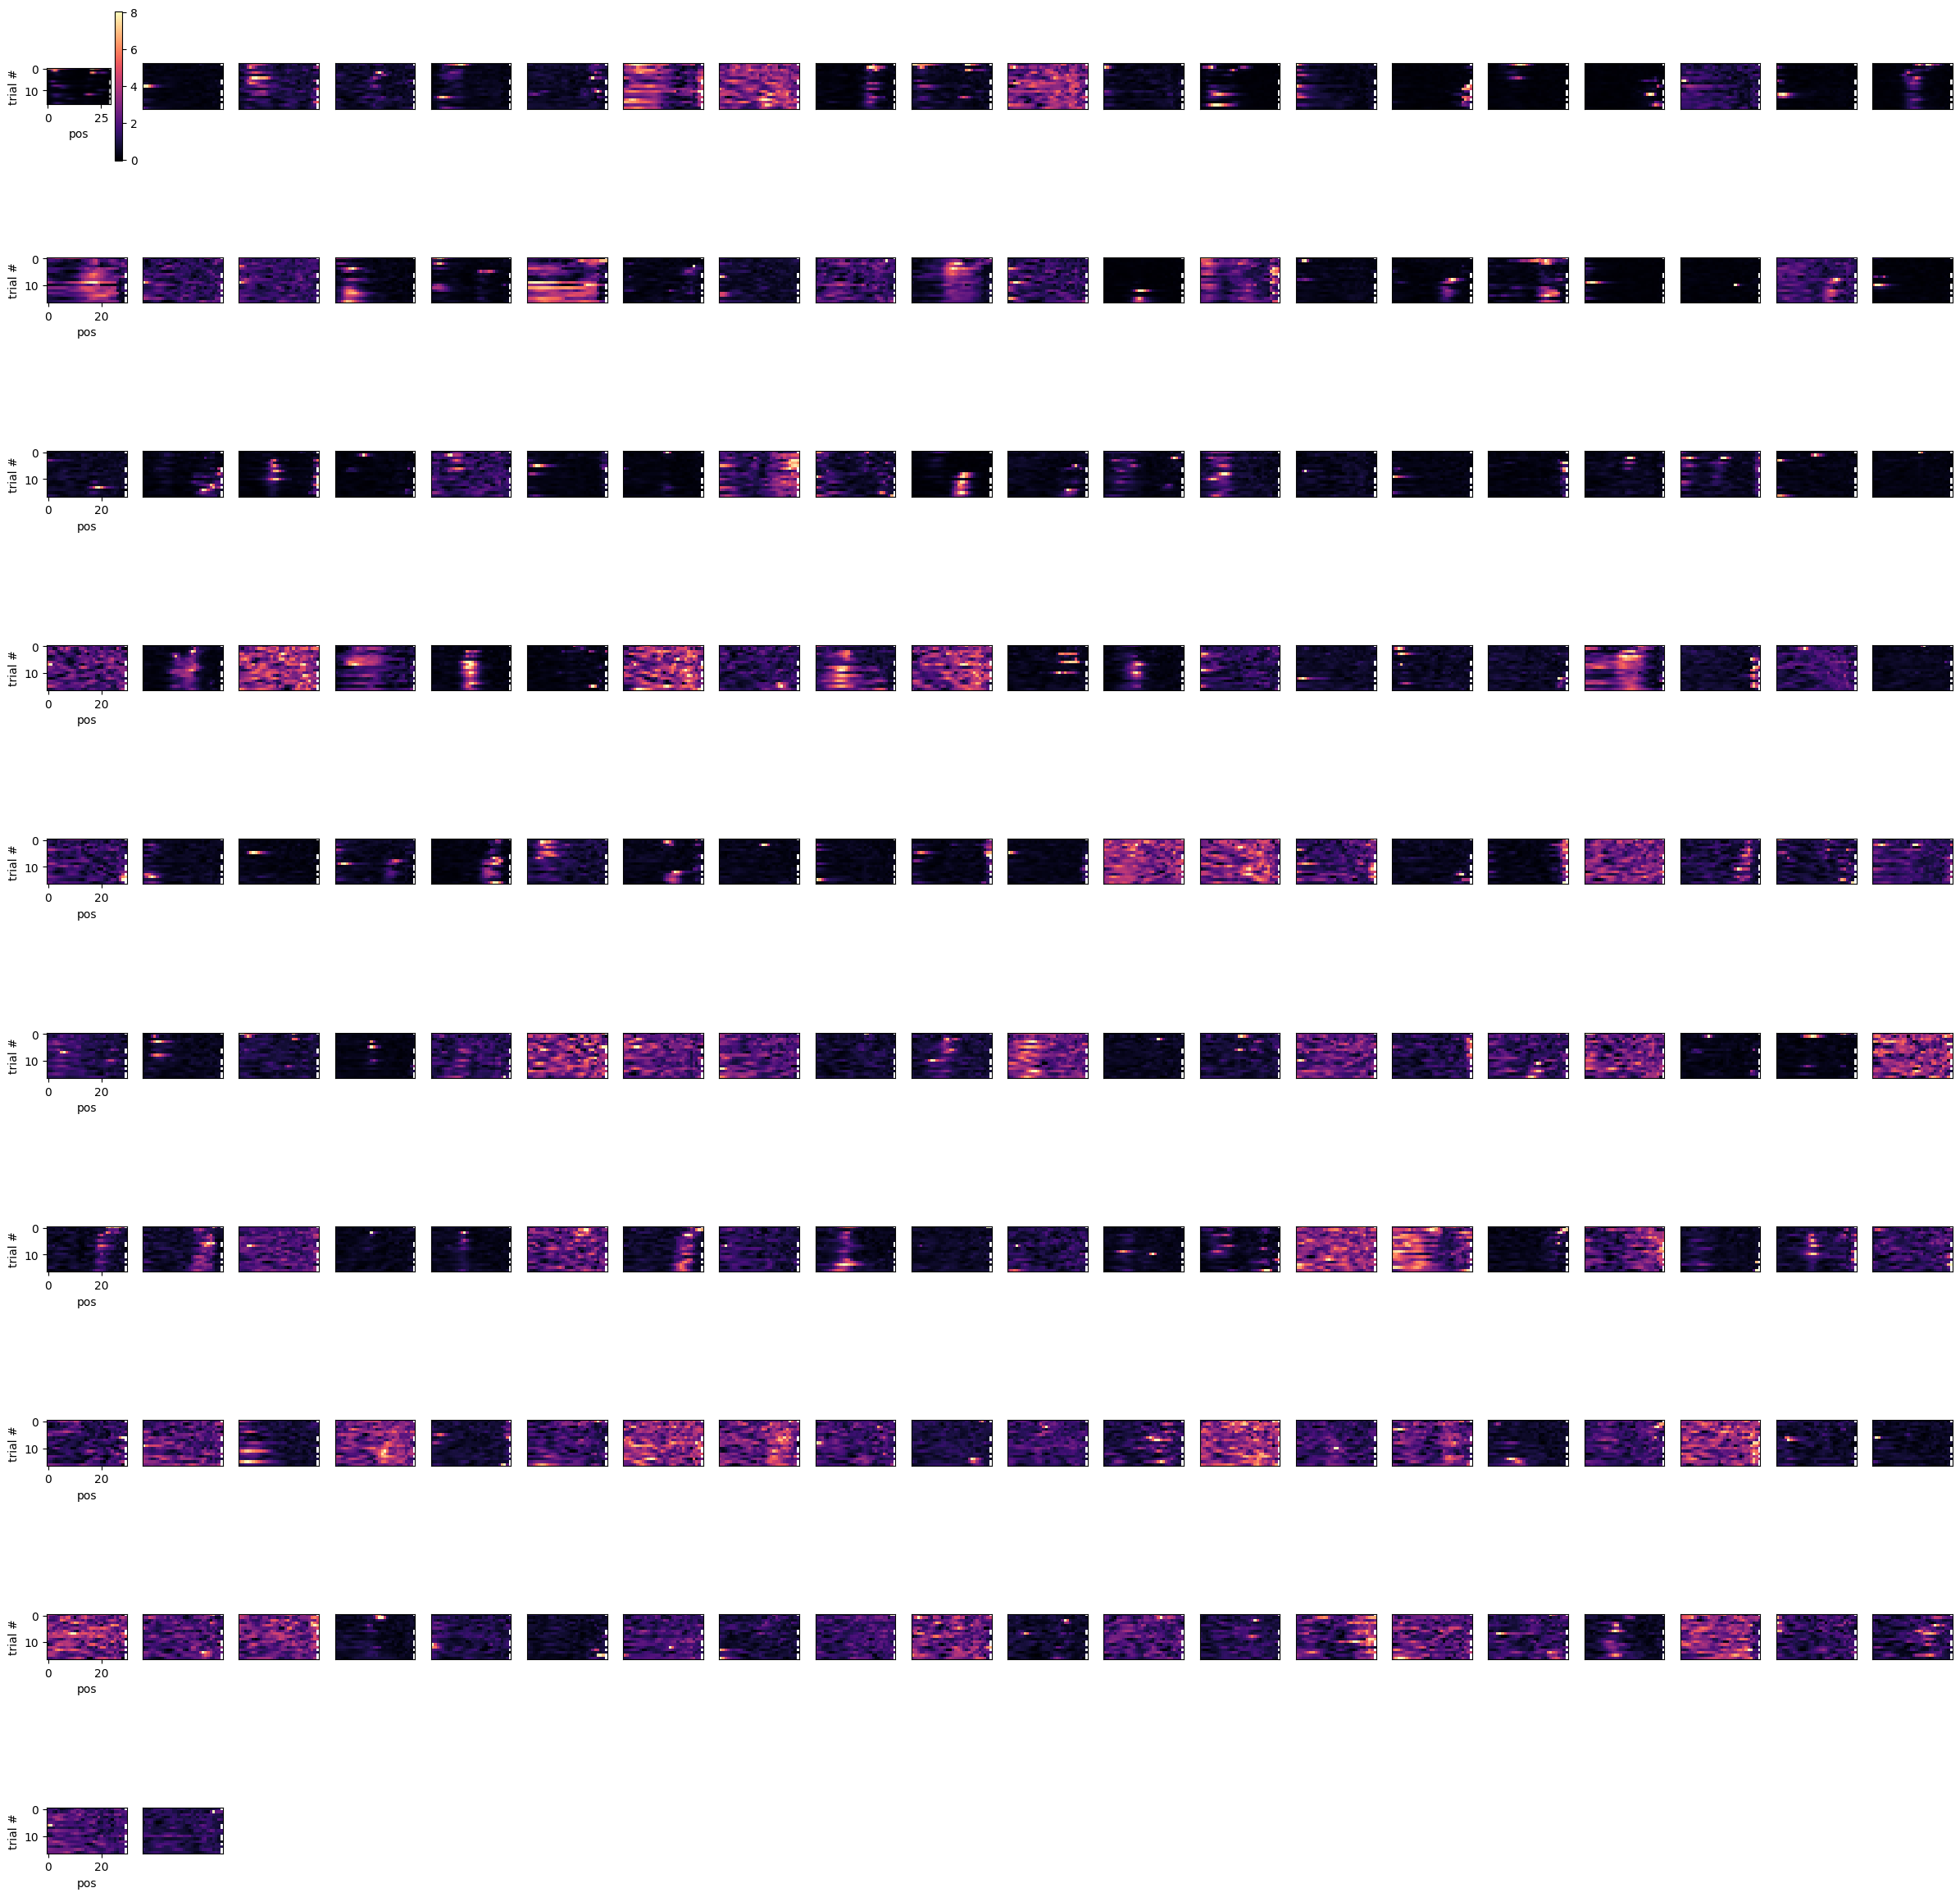

In [60]:
trial_mask = sess.trial_info['LR']==sess.novel_arm

cell_mask=field_perm_masks['cell_masks']['channel_0']['nov']
fig = u.plot_cells(sess.trial_matrices['channel_0_F_dff'][trial_mask,:,:][:,:,cell_mask])




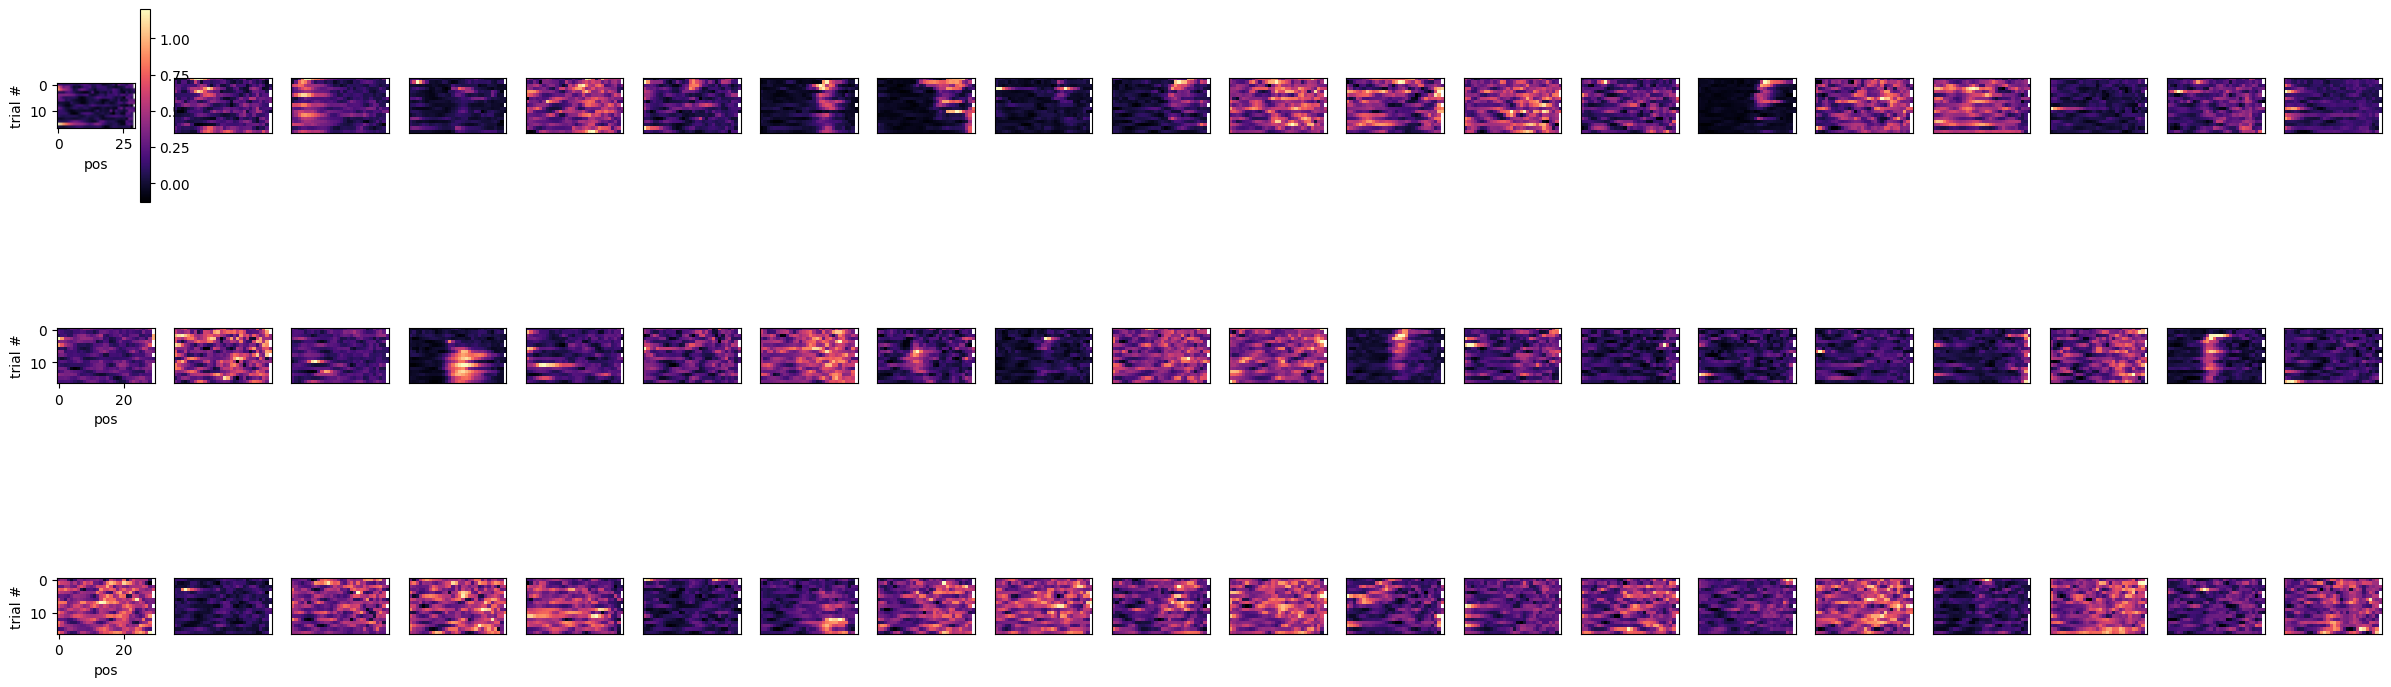

In [62]:
cell_mask=field_perm_masks['cell_masks']['channel_1']['nov']
fig = u.plot_cells(sess.trial_matrices['channel_1_F_dff'][trial_mask,:,:][:,:,:])